In [1]:
from fits_io import scan_dataset, update_headers, dataset_metadata, object_in_fov
from fits_io import identify_objects, cleanup_intermediate_files 
from fits_io import flag_object_in_fov, load_dataset_objects
from reduccion import run_reduction, plot_reduction
from astrometria import run_astrometry
from stars_catalog import generate_refcat, plot_catalog_on_image
from combine import process_and_combine_images, plot_combined, remove_aligment_tempfiles, plot_alignment, plot_alignment_qc
import pandas as pd
from pathlib import Path
import os
from utils import load_config, Tee, load_target_coordinates, append_last_row
from datetime import datetime
import sys
from autophot.autophot_main import run_automatic_autophot
import tempfile
import shutil
from autophot.prep_input import load
from image_qc import run_image_qc, plot_qc_panel,  plot_qc_advanced
import numpy as np
import traceback




# -----------------------------------------------------------------------------
# Load settings
# -----------------------------------------------------------------------------

config_file="config.yaml"
cfg = load_config(config_file)

BASE = Path(cfg["paths"]["BASE"])
data_path = Path(BASE, cfg["paths"]["data_dir"])
object_path = Path(data_path, cfg["paths"]["objects_dir"])
night = cfg["night"]
night_dir = Path(data_path, night)
objects_csv = Path(object_path, "objetos.csv")
images_file_name = cfg["paths"]["images_data_file"]
images_file = Path(night_dir, images_file_name)


gain = cfg["instrument"]["gain"]
rdnoise = cfg["instrument"]["rdnoise"]

steps = cfg["steps"]

print(f"Running pipeline in night dir: {night_dir}")
# -------------------------------------------------------------------------
# Redirect stdout/stderr to a single log file (append)
# -------------------------------------------------------------------------
log_file = night_dir / "pipeline.log"
#sys.stdout = Tee(log_file)
#sys.stderr = sys.stdout

print("\n"*2 + "="*80)
print(f"New pipeline run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


# -------------------------------------------------------------------------
# 1) Scan dataset
# -------------------------------------------------------------------------
dataset = scan_dataset(night_dir)

# -------------------------------------------------------------------------
# 2) Update headers
# -------------------------------------------------------------------------
if steps.get("update_headers", False):
    print("→ Updating FITS headers")
    update_headers(dataset["all"], gain=gain, rdnoise=rdnoise)

# -------------------------------------------------------------------------
# 3) Export metadata
# -------------------------------------------------------------------------
if steps.get("export_metadata", False):
    print(f"→ Exporting metadata to {images_file}")
    metadata_file = dataset_metadata(dataset, night_dir, output_file=images_file,
                                         objects_csv=objects_csv)
    # Load objects list
    objects = load_dataset_objects(night_dir, images_file)
    
    # Create a folder in objects dir for each object
    for objname in objects:
        obj_dir = Path(object_path, objname)
        obj_dir.mkdir(parents=True, exist_ok=True)


# -------------------------------------------------------------------------
# 4) Reduction
# -------------------------------------------------------------------------
if steps.get("reduction", False):
    print("→ Running reduction")

    reduction_cfg = cfg.get("reduction", {})
    reduction_result = run_reduction(
        dataset=dataset,
        zero_correction=reduction_cfg.get("zero_correction", True),
        flat_correction=reduction_cfg.get("flat_correction", True),
        dark_correction=reduction_cfg.get("dark_correction", False),
    )
else:
    reduction_result = None
    
# -------------------------------------------------------------------------
# 4.a) Plot de reducción
# -------------------------------------------------------------------------
if cfg["qc"].get("reduction_images", False):
    print("→ [QC] Generating reduction plots")
    for objname in objects:
        print(f"   → Object: {objname}")

        plot_reduction(
            dataset=str(images_file),
            night_dir=night_dir,
            objname=objname,
            output_name=f"reduction_{objname}.png",
            show=False,
            overwrite=True
        )
    print("✓ [QC] Reduction plots generated")

# -------------------------------------------------------------------------
# 5) Astrometry
# -------------------------------------------------------------------------
if steps.get("astrometry", False):
    print("→ Running astrometry")

    astro_cfg = cfg.get("astrometry", {})
    run_astrometry(
        dataset=dataset,
        output_dir=night_dir,
        api_key=astro_cfg["api_key"],
        overwrite=astro_cfg.get("overwrite", True),
    )
    dataset = scan_dataset(night_dir)
    metadata_file = dataset_metadata(dataset, night_dir,
                                    output_file=images_file)

# -------------------------------------------------------------------------
# 5.a) Images contains its object?
# -------------------------------------------------------------------------
if steps.get("contains_obj", False):
    print("→ Flagging not contained images")
    df = flag_object_in_fov(metadata_file,
                       objects_csv,
                       night_dir,
                       overwrite=False)
    metadata_file = dataset_metadata(dataset, night_dir,
                                    output_file=images_file)
    
# -------------------------------------------------------------------------
# 5.b) Sanity check: filtro de imágenes válidas
# -------------------------------------------------------------------------
if steps.get("image_qc", False):
    print("→ Running image QC module")

    qc_cfg = cfg["qc"]["image_qc"]
    ds = pd.read_csv(images_file)
    for objname in objects:
        ra, dec = load_target_coordinates(objname, objects_csv)
        mask = (
            ds["CALIBZ"].str.contains("bias", case=False, na=False) &
            (ds["ASTROMET"] == "yes") &
            ds["CALIBF"].str.contains("flat", case=False, na=False) &
            (ds["CONTAINS_OBJECT"] == True) &
            ds["FILENAME"].str.endswith("_wcs.fits") &
            (ds["OBJECT"] == objname)    
        )
        ds_filtered = ds[mask].copy()

        if ds_filtered.empty:
            print("   No images match QC criteria.")
        else:
            print(f"   Processing {len(ds_filtered)} images...")

        # Ensure QC columns exist
        qc_cols = ["QC_NSRCS", "QC_FWHM", "QC_ELLIP", "QC_USE", "QC_FLAGS", "QC_DATE"]
        for col in qc_cols:
            if col not in ds.columns:
                ds[col] = np.nan

        approved = rejected = 0

        for idx, row in ds_filtered.iterrows():
            fits_path = night_dir / row["FILENAME"]
            if idx == ds_filtered.iloc[0].name:
                astro_cat_path = generate_refcat(
                    objname=objname, ra_center=ra, dec_center=dec,
                    img_path=fits_path, objects_dir=object_path,
                    fov_frac=0.4,
                    min_mag=5,
                    max_mag=16,
                    max_mag_err=2,
                    use_catalogs="all",
                    plot=True,
                    type="astro",
                    overwrite=True
                )
            print(f"   → QC on {fits_path.name}")

            try:
                metrics, use, flags = run_image_qc(fits_path, qc_cfg, night_dir)

                ds.loc[idx, "QC_NSRCS"] = metrics.get("n_sources", np.nan)
                ds.loc[idx, "QC_FWHM"]   = metrics.get("fwhm", np.nan)
                ds.loc[idx, "QC_ELLIP"]  = metrics.get("ellipticity", np.nan)
                ds.loc[idx, "QC_USE"]    = use
                ds.loc[idx, "QC_FLAGS"]  = flags
                ds.loc[idx, "QC_DATE"]   = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

                status = "APPROVED" if use else "REJECTED"
                print(f"      {status} | n_src: {metrics.get('n_sources', 'N/A')}, "
                    f"FWHM: {metrics.get('fwhm', 'N/A'):.2f}, "
                    f"Ellip: {metrics.get('ellipticity', 'N/A'):.2f}, Flags: {flags}")

                if use:
                    approved += 1
                else:
                    rejected += 1
                
                if qc_cfg.get("plot", False):
                    print(f"      → Plotting QC panel")
                    #plot_qc_panel(fits_path, night_dir/"qc_outputs"/f"{fits_path.stem}_cat.txt", metrics, night_dir/"qc_outputs")
                    plot_qc_advanced(fits_path, night_dir/"qc_outputs"/f"{fits_path.stem}_cat.txt", 
                                    astro_cat_path, (ra,dec), night_dir/"qc_outputs")

                    print(f"      QC panels saved in: {night_dir / 'qc_outputs'}/*.png")

            except Exception as e:
                print(f"      Error on {fits_path.name}: {str(e)}")
                ds.loc[idx, "QC_FLAGS"] = f"ERROR: {str(e)[:50]}..."
                traceback.print_exc()
                rejected += 1

    ds.to_csv(images_file, index=False)
    print("      ✓ Image QC finished")

    # Summary
    total = approved + rejected
    rate = (approved / total * 100) if total > 0 else 0
    print(f"\nSummary: {total} processed | {approved} approved ({rate:.1f}%) | {rejected} rejected")

    if approved > 0:
        good = ds[ds["QC_USE"] == True]
        print(f"Median FWHM approved: {good['QC_FWHM'].median():.2f} px")
        print(f"Median n_sources approved: {good['QC_NSRCS'].median():.0f}")



# -------------------------------------------------------------------------
# 6) Combination
# -------------------------------------------------------------------------
if steps.get("combine", False):
    print("→ Combining images per object and filter")
    
    filters = cfg.get("filters", ["I", "V"])
    for objname in objects:
        print(f"   → Object: {objname}")
        print(f"      → Generating reference catalog")
        # Load metadata for the object
        ra, dec = load_target_coordinates(objname, objects_csv)
        alig_cfg = cfg.get("aligment", {})["catalog"]
        # Load image path for the object
        ds = pd.read_csv(Path(night_dir, images_file))
        img_files = ds[(ds["OBJECT"]==objname)&(ds["ASTROMET"]=="yes")]["FILENAME"].values
        img_path = night_dir / img_files[0]

        alig_cat_path = generate_refcat(
            objname=objname, ra_center=ra, dec_center=dec,
            img_path=img_path, objects_dir=object_path,
            fov_frac=alig_cfg.get("fov_frac", 0.3),
            min_mag=alig_cfg.get("min_mag", 9),
            max_mag=alig_cfg.get("max_mag", 12),
            use_catalogs=alig_cfg.get("use_catalogs", "all"),
            plot=alig_cfg.get("plot", False),
            overwrite=alig_cfg.get("overwrite", False),
        )

        for filt in filters:
            print(f"      → Filter: {filt}")
            images_to_combine = [night_dir / im for im in img_files if im[-14].upper() == filt.upper()]
            if len(images_to_combine) == 0:
                print(f"         ! No images found for filter {filt}. Skipping.")
                continue
            print(f"         ✓ Found {len(images_to_combine)} images for filter {filt}.")
            combined_im = process_and_combine_images(images_to_combine, objname,  filt, object_path, night_dir, objects_csv)
            # Plot aligment reference catalog on combined images (unnecessary step)
            plot_catalog_on_image(fits_file=combined_im,
                                  catalog=alig_cat_path,
                                  obj_ra=ra,
                                  obj_dec=dec,
                                  out_png=Path(night_dir, f"{objname}{filt}_comb_alig_cat.png"),
                                  title=f"{objname} – Aligment catalog")
            if cfg["qc"].get("aligment_images", False):
                dataset = scan_dataset(night_dir)
                metadata_file = dataset_metadata(dataset, night_dir,
                                    output_file=images_file)
                print("      → [QC] Plotting aligment images")
                plot_alignment(
                    dataset=str(images_file),
                    night_dir=night_dir,
                    objname=objname,
                    filter_band=filt,
                    obj_ra=ra, obj_dec=dec,
                    output_name=f"aligment_{objname}.png",
                    show=False,
                    overwrite=True
                )
            if cfg["combine"].get("remove_temp_files", False):
                print("      → Removing temporary files")
                removed = remove_aligment_tempfiles(filt, night_dir)
    dataset = scan_dataset(night_dir)
    metadata_file = dataset_metadata(dataset, night_dir,
                                    output_file=images_file)
    

if cfg["qc"].get("combined_images", False):
    print("→ Generating combined plots")
    for objname in objects:
        print(f"   → Object: {objname}")
        image_files = [file for file in dataset["images_combined"] if objname in file.name]
        if len(image_files) == 0:
            print(f"      ! No combined images found for object {objname}. Skipping.")
            continue  
        plot_combined(objname, image_files,  night_dir, show=False)
        
        
if steps.get("photometry", False):
    print("→ Photometry on science images")
    phot_cfg = cfg["photometry"]
    img_files = []
    if phot_cfg["on_exp"]:
        img_files += dataset["images_astro"]
    if phot_cfg["on_comb"]:
        img_files += dataset["images_combined"]
         
    for objname in objects:
        print(f"   → Object: {objname}")
        print(f"      → Generating reference catalog")
        ra, dec = load_target_coordinates(objname, objects_csv)
        phot_cat_cfg = cfg["photometry"]["catalog"]
        img_path = night_dir / img_files[0]
        phot_cat_path = generate_refcat(
            objname=objname, ra_center=ra, dec_center=dec,
            img_path=img_path, objects_dir=object_path,
            fov_frac=phot_cat_cfg.get("fov_frac", 0.3),
            min_mag=phot_cat_cfg.get("min_mag", 9),
            max_mag=phot_cat_cfg.get("max_mag", 12),
            max_mag_err=phot_cat_cfg.get("max_mag_err", 0.25),
            use_catalogs=phot_cat_cfg.get("use_catalogs", False),
            plot=phot_cat_cfg.get("plot", False),
            type="phot",
            overwrite=phot_cat_cfg.get("overwrite", False)
        )
        print(f"      → [QC] Plotting catalog on combined image")
        combined_im = [f for f in dataset["images_combined"] if objname in f.name][0]
        plot_catalog_on_image(fits_file=combined_im,
                        catalog=phot_cat_path,
                        obj_ra=ra,
                        obj_dec=dec,
                        out_png=Path(object_path, objname, f"{objname}_phot_cat.png"),
                        title=f"{objname} – Aligment catalog")
        
        print("   → Photometry settings")
        image_files = []
        if phot_cfg["on_comb"]:
            image_files+=[f for f in dataset["images_combined"] if objname.lower() in str(f).lower()]
        if phot_cfg["on_exp"]:
            image_files+=[f for f in dataset["images_astro"] if objname.lower() in str(f).lower()]

        refcat_csv = os.path.join(BASE, "data", "objetos", objname, f"{objname}_phot_cat.csv")
        fits_dir = os.path.join(BASE, "data", night, objname, "phot")
        os.makedirs(fits_dir, exist_ok=True)
        for im in image_files:
            shutil.copy(im, Path(fits_dir, im.name))
        wdir = os.path.join(BASE, "outputs", night, objname)
        os.makedirs(wdir, exist_ok=True)

        #autophot_input = load()
        autophot_input = phot_cfg["autophot"]
        autophot_input["wdir"] = wdir
        autophot_input["fits_dir"] = fits_dir

        autophot_input["target_name"] = objname
        autophot_input["target_ra"] = ra/15
        autophot_input["target_dec"] = dec

        autophot_input["catalog"]["use_catalog"] = "custom"
        autophot_input["catalog"]["catalog_custom_fpath"] = refcat_csv
        shutil.copy("telescope.yml", Path(wdir, "telescope.yml"))

        try:
            run_automatic_autophot(autophot_input)
            os.chdir(BASE)
            print(f"         ✓ AutoPhOT completado para {objname}")
        except Exception as e:
            print(f"         Error AutoPhOT {objname}: {str(e)}")
            continue

        append_last_row(
            Path(night_dir, objname, "phot_REDUCED","REDUCED.csv"),
            Path(object_path, objname, "lightcurve.csv"),
            n_rows=len(image_files)
        )
        
        # Delete calibrated intermediate science images ? bias, flats
        # Delete duplicated images copied to run photometry?
 
print("✓ Pipeline finished successfully")


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Running pipeline in night dir: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis


New pipeline run: 2026-02-04 11:12:21
→ Exporting metadata to /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/images_data.csv


   Processing FITS files: 100%|██████████| 498/498 [00:00<00:00, 89149.10it/s]

→ Running image QC module
   Processing 12 images...
         Sobrescribiendo archivo /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/OGLE-2025-BLG-0451/OGLE-2025-BLG-0451_astro_cat.csv
         FOV diagonal: 13.5' → Search radius: 5.4'
         Buscando en Gaia...
            • Gaia → 293 refs
      ✓ Archivo /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/OGLE-2025-BLG-0451/OGLE-2025-BLG-0451_astro_cat.csv generado correctamente (293 refs).


      ✓ Plot saved: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/objetos/OGLE-2025-BLG-0451/OGLE-2025-BLG-0451_astro_cat.png 
   → QC on FBOGLE-2025-BLG-0451v0001_wcs.fits
Catalog generated: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0001_wcs_cat.txt
      Detected objects: 944
      SNR_WIN - min: -1.86, max: 840.30, mean: 34.72, NaNs: 0
      Objects with FLAGS==0: 819
      Objects with SNR > 5: 939
      Objects good (FLAGS=0 and SNR>5): 814
      APPROVED | n_src: 814, FWHM: 4.00, Ellip: 0.09, Flags: 
      → Plotting QC panel
   → Cargado catálogo astrométrico: 293 entradas
✓ Guardado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0001_wcs_qc_advanced.png
      QC panels saved in: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/*.png
   → QC on FBOGLE-2025-BLG-0451v0002_

Fuentes con match < 1″ : 292
Fuentes sin match               : 772
Total good                      : 1064
Objeto plotteado en píxeles: (650.7, 532.5)


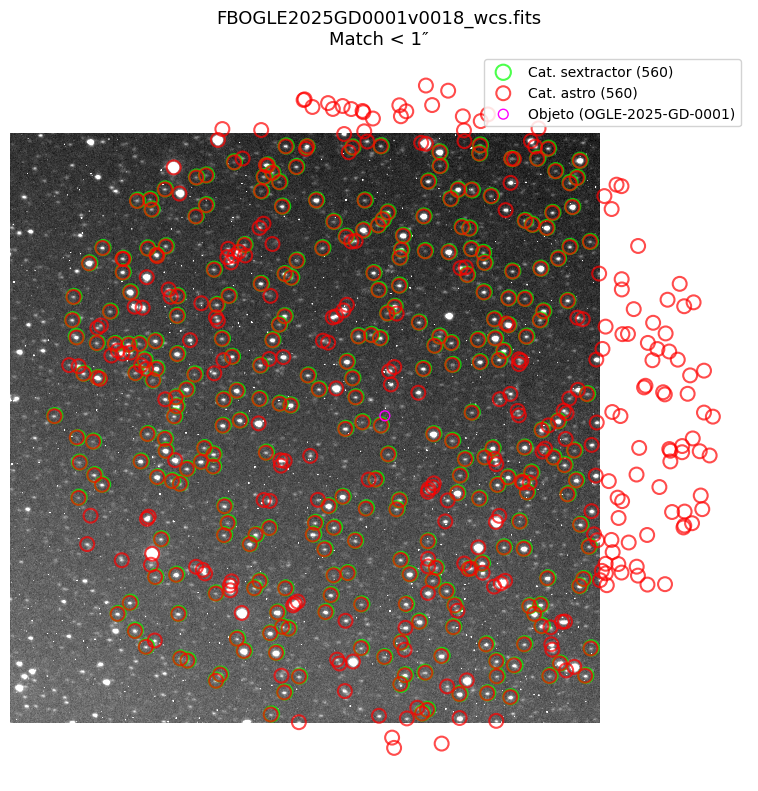

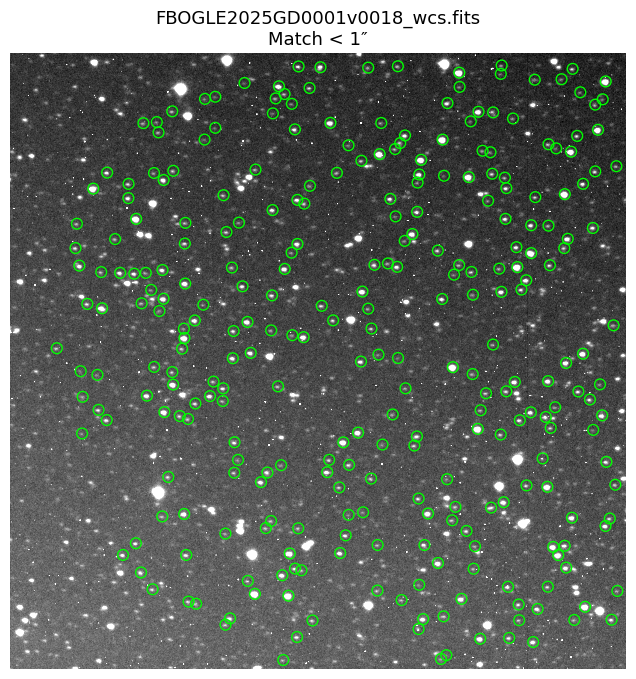

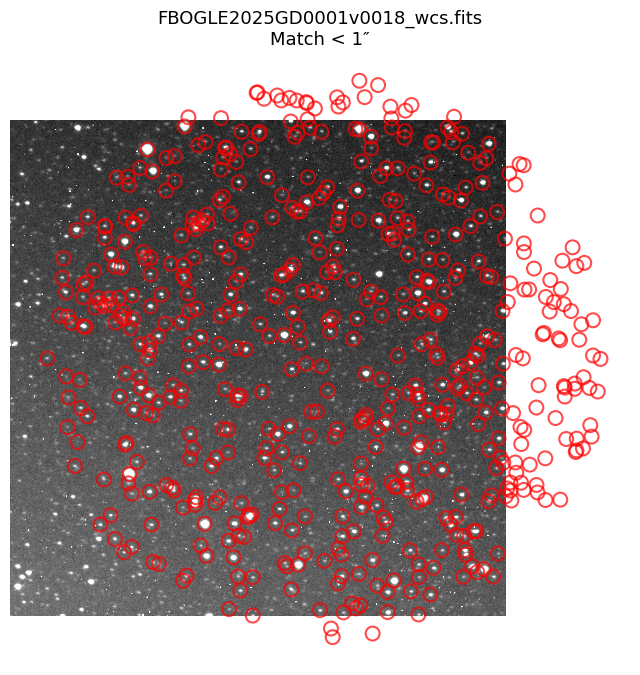

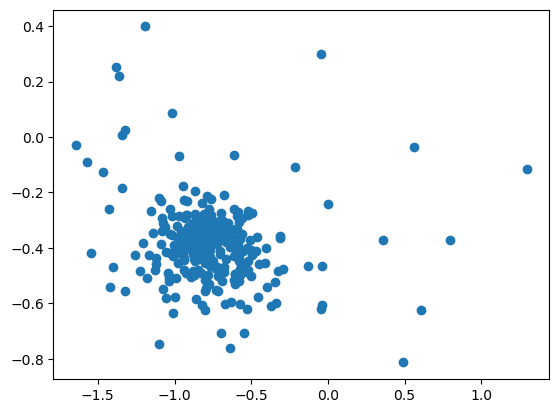

In [3]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
from pathlib import Path
%matplotlib inline

# ── Configuración ────────────────────────────────────────────────────────

cat_path  = night_dir/"qc_outputs"/f"{fits_path.stem}_cat.txt"                  # cambiar
astrom_cat_path = object_path/objname/f"{objname}_phot_cat.csv"


max_sep_arcsec = 1   # umbral para considerar un "match" bueno

# ── Leer imagen y WCS ────────────────────────────────────────────────────
with fits.open(fits_path) as hdul:
    data = hdul[0].data.astype(float).squeeze()
    w = WCS(hdul[0].header)

# Normalización
norm = ImageNormalize(data, interval=ZScaleInterval())

# ── Leer catálogos ───────────────────────────────────────────────────────
df_sex = pd.read_csv(cat_path, comment="#", delim_whitespace=True, header=None)
column_names = [
    "NUMBER", "X_IMAGE", "Y_IMAGE", "FLUX_AUTO", "FLUXERR_AUTO",
    "MAG_AUTO", "MAGERR_AUTO", "FWHM_IMAGE", "ELLIPTICITY", "THETA_IMAGE",
    "FLAGS", "SNR_WIN", "FLUX_APER_1", "FLUXERR_APER_1",
]
df_sex.columns = column_names[:df_sex.shape[1]]

good = df_sex[(df_sex["FLAGS"] == 0) & (df_sex["FWHM_IMAGE"] > 0)
              & (df_sex["FLUX_AUTO"]<40000)
              & (df_sex["SNR_WIN"] > 5)].copy()

df_astrom = pd.read_csv(astro_cat_path)

# ── Convertir píxeles → RA/DEC ───────────────────────────────────────────
ra_sex, dec_sex = w.all_pix2world(good["X_IMAGE"], good["Y_IMAGE"], 0)

coord_sex = SkyCoord(ra=ra_sex * u.deg, dec=dec_sex * u.deg, frame='icrs')
#coord_ref = SkyCoord(ra=df_astrom["RA"].values * u.deg,
#                     dec=df_astrom["DEC"].values * u.deg, frame='icrs')
from astropy.time import Time
from astropy.coordinates import SkyCoord


obs_time = Time(hdul[0].header['DATE-OBS'])


if 'pmRA' in df_astrom.columns and 'pmDE' in df_astrom.columns:
    # Crear SkyCoord con PM y época
    coord_ref = SkyCoord(
        ra=df_astrom["RA"].values * u.deg,
        dec=df_astrom["DEC"].values * u.deg,
        pm_ra_cosdec=df_astrom["pmRA"].values * u.mas/u.yr,   # o pm_ra_cosdec
        pm_dec=df_astrom["pmDE"].values * u.mas/u.yr,
        obstime=Time('J2016.0'),  # época de Gaia DR3
        frame='icrs'
    )

    # Aplicar proper motion hasta época de observación
    coord_ref_at_obs = coord_ref.apply_space_motion(new_obstime=obs_time)

    # Usar las posiciones corregidas
    ra_ref_corrected = coord_ref_at_obs.ra.deg
    dec_ref_corrected = coord_ref_at_obs.dec.deg

    coord_ref = SkyCoord(ra=ra_ref_corrected * u.deg,
                         dec=dec_ref_corrected * u.deg,
                         frame='icrs')
else:
    print("Advertencia: No se encontró PM en Gaia DR3 → no se corrige época")
    coord_ref = SkyCoord(ra=df_astrom["RA"].values * u.deg,
                         dec=df_astrom["DEC"].values * u.deg,
                         frame='icrs')
# Matching
idx, sep, _ = coord_sex.match_to_catalog_sky(coord_ref)

# ── Clasificar fuentes ───────────────────────────────────────────────────
has_match = sep < max_sep_arcsec * u.arcsec

matched = good[has_match].copy()
unmatched = good[~has_match].copy()

print(f"Fuentes con match < {max_sep_arcsec}″ : {len(matched)}")
print(f"Fuentes sin match               : {len(unmatched)}")
print(f"Total good                      : {len(good)}")

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(data, origin='lower', cmap='gray', norm=norm)
ax.set_title(f"{fits_path.name}\nMatch < {max_sep_arcsec}″", fontsize=13)
ax.axis('off')
'''
# Fuentes con match → verde claro / círculo más pequeño
if not matched.empty:
    ax.scatter(matched["X_IMAGE"], matched["Y_IMAGE"],
               s=60, facecolor='none', edgecolor='lime', lw=1,
               label=f"Matched ({len(matched)})")

# Fuentes sin match → rojo / círculo más grande para destacar
if not unmatched.empty:
    ax.scatter(unmatched["X_IMAGE"], unmatched["Y_IMAGE"],
               s=90, facecolor='none', edgecolor='red', lw=2.0, alpha=0.9,
               label=f"Unmatched ({len(unmatched)})")
'''
if not good.empty:
    # Convertir RA/DEC del catálogo de referencia a píxeles en la imagen
    x_ref, y_ref = w.all_world2pix(ra_sex, dec_sex , 0)
    
    ax.scatter(matched["X_IMAGE"], matched["Y_IMAGE"],
               s=120, facecolor='none', edgecolor='lime', lw=1.5, alpha=0.7,
               label=f"Cat. sextractor ({len(df_astrom)})")

if not df_astrom.empty:
    # Convertir RA/DEC del catálogo de referencia a píxeles en la imagen
    x_ref, y_ref = w.all_world2pix(df_astrom["RA"].values, 
                                   df_astrom["DEC"].values, 0)
    
    ax.scatter(x_ref, y_ref,
               s=100, facecolor='none', edgecolor='red', lw=1.5, alpha=0.7,
               label=f"Cat. astro ({len(df_astrom)})")

ra, dec = load_target_coordinates(objname, objects_csv)

try:
    x_obj, y_obj = w.all_world2pix(ra, dec, 0)  # 1 = pixel center
    ax.scatter(x_obj, y_obj, facecolor='none', edgecolor='magenta', s=50, lw=1,
            label=f"Objeto ({objname})")
    print(f"Objeto plotteado en píxeles: ({x_obj:.1f}, {y_obj:.1f})")
except Exception as e:
    print(f"Error al convertir ra/dec del objeto a píxeles: {e}")


ax.legend(loc='upper right', fontsize=10, framealpha=0.85)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(data, origin='lower', cmap='gray', norm=norm)
ax.set_title(f"{fits_path.name}\nMatch < {max_sep_arcsec}″", fontsize=13)
ax.axis('off')

# Fuentes con match → verde claro / círculo más pequeño
if not matched.empty:
    ax.scatter(matched["X_IMAGE"], matched["Y_IMAGE"],
               s=60, facecolor='none', edgecolor='lime', lw=1,
               label=f"Matched ({len(matched)})")
plt.show()

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(data, origin='lower', cmap='gray', norm=norm)
ax.set_title(f"{fits_path.name}\nMatch < {max_sep_arcsec}″", fontsize=13)
ax.axis('off')
x_ref, y_ref = w.all_world2pix(df_astrom["RA"].values, 
                                df_astrom["DEC"].values, 0)

ax.scatter(x_ref, y_ref,
            s=100, facecolor='none', edgecolor='red', lw=1.5, alpha=0.7,
            label=f"Cat. astro ({len(df_astrom)})")
plt.show()


ra_diff = (coord_sex.ra - coord_ref[idx].ra).to(u.arcsec).value[has_match]
dec_diff = (coord_sex.dec - coord_ref[idx].dec).to(u.arcsec).value[has_match]

plt.scatter(ra_diff, dec_diff)

# Opcional: guardar
# plt.savefig(f"match_test_{fits_path.stem}.png", dpi=180, bbox_inches='tight')

In [ ]:
f_sex

34     171.0688
35     331.3726
36     277.7982
40     216.2328
43     781.7792
         ...   
885    777.9261
893    719.2910
894    448.7230
904    509.7484
920    223.6727
Name: X_IMAGE, Length: 224, dtype: float64

In [11]:
import subprocess
import os
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, ZScaleInterval
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
import numpy as np
import subprocess
import pandas as pd
import numpy as np
from pathlib import Path
from shutil import copyfile
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.visualization.stretch import LogStretch


import matplotlib.pyplot as plt

# =====================================================
# Always create valid default SExtractor files
# =====================================================

def ensure_sextractor_files(outdir: Path, custom_params=None, custom_conv=None):
    outdir.mkdir(exist_ok=True)

    param_file = outdir / "default.param"
    sex_file   = outdir / "default.sex"
    conv_file  = outdir / "default.conv"

    # ---------------- default.param (mismo, no cambia para tests) ----------------
    param_file.write_text(
        "NUMBER\n"
        "X_IMAGE\n"
        "Y_IMAGE\n"
        "FLUX_AUTO\n"
        "FLUXERR_AUTO\n"
        "MAG_AUTO\n"
        "MAGERR_AUTO\n"
        "FWHM_IMAGE\n"
        "ELLIPTICITY\n"
        "THETA_IMAGE\n"
        "FLAGS\n"
        "SNR_WIN\n"
        "FLUX_APER(1)\n"          
        "FLUXERR_APER(1)\n"
    )

    # ---------------- default.conv (permite custom) ----------------
    sextractor_share = Path("/home/knowogrodski/miniconda3/envs/hsh_images/share/sextractor")
    official_conv = sextractor_share / "default.conv"

    if custom_conv:
        conv_file.write_text(custom_conv)
        print("Usando conv customizado")
    elif official_conv.exists():
        copyfile(official_conv, conv_file)
    else:
        conv_file.write_text("""CONV NORM
# 3x3 Gaussian-like convolution mask (standard for star detection)
3 3
1 2 1
2 4 2
1 2 1
""")

    # ---------------- default.sex (permite custom_params como dict) ----------------
    default_settings = (
        "CATALOG_TYPE       ASCII_HEAD\n"
        "DETECT_TYPE        CCD\n"
        "DETECT_MINAREA     5\n"
        "DETECT_THRESH      1.5\n"
        "ANALYSIS_THRESH    1.5\n"
        "DEBLEND_NTHRESH    32\n"
        "DEBLEND_MINCONT    0.005\n"
        "CLEAN              Y\n"
        "CLEAN_PARAM        1.0\n"
        "PHOT_APERTURES     3,5,8\n"           # multiple apertures for robustness
        "PHOT_AUTOPARAMS    2.5,3.5\n"
        "PHOT_FLUXFRAC      0.5\n"
        "SATUR_LEVEL        50000\n"
        "MAG_ZEROPOINT      25.0\n"
        "GAIN               1.0\n"
        "PIXEL_SCALE        1.0\n"
        "SEEING_FWHM        2.0\n"
        "BACK_SIZE          64\n"
        "BACK_FILTERSIZE    3\n"
        "CHECKIMAGE_TYPE    NONE\n"
        "MEMORY_OBJSTACK    3000\n"
        "MEMORY_PIXSTACK    300000\n"
        "MEMORY_BUFSIZE     1024\n"
        "VERBOSE_TYPE       QUIET\n"           # change to NORMAL for more info
    )

    if custom_params:
        settings = default_settings.splitlines()
        for key, value in custom_params.items():
            for i, line in enumerate(settings):
                if line.strip().startswith(key):
                    settings[i] = f"{key} {value}"
                    break
            else:
                settings.append(f"{key} {value}")
        sex_file.write_text("\n".join(settings))
        print("Configuración customizada aplicada a default.sex")
    else:
        sex_file.write_text(default_settings)


# =====================================================
# Run SExtractor
# =====================================================

def run_sextractor(fits_path: Path, outdir: Path, test_name="default", 
                   custom_params=None, custom_conv=None, overwrite=False) -> Path:
    ensure_sextractor_files(outdir, custom_params, custom_conv)

    sex_file   = outdir / "default.sex"
    param_file = outdir / "default.param"
    conv_file  = outdir / "default.conv"
    cat_path   = outdir / f"{fits_path.stem}_cat_{test_name}.txt"

    if cat_path.exists() and not overwrite:
        print(f"         Omitiendo: {cat_path} ya existe.")
        return cat_path

    cmd = [
        "sex", str(fits_path),
        "-c", str(sex_file),
        "-CATALOG_NAME", str(cat_path),
        "-PARAMETERS_NAME", str(param_file),
        "-FILTER", "Y",
        "-FILTER_NAME", str(conv_file),
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("\n===== Command executed =====")
        print(" ".join(cmd))
        print("\n===== Content of default.conv =====")
        print(conv_file.read_text())
        print("\n===== Content of default.sex =====")
        print(sex_file.read_text())
        print("\n===== SExtractor STDOUT =====")
        print(result.stdout)
        print("\n===== SExtractor STDERR =====")
        print(result.stderr)
        raise RuntimeError("SExtractor failed")

    print(f"      ✓ Catálogo generado: {cat_path}")
    return cat_path

# =====================================================
# Función para testear múltiples configs de SExtractor
# =====================================================

def test_sextractor_configs(fits_path: Path, outdir: Path, astrom_cat_path: Path,
                            configs, max_sep_arcsec=1.0, plot=True):
    """
    Testea múltiples configuraciones de SExtractor:
    - Corre SExtractor con cada config
    - Calcula matches con catálogo astrométrico
    - Plotea imagen con fuentes matched (verde) y no matched (rojo)
    - Imprime stats (n_detected, n_matched, RMS residuales)
    
    configs: lista de dicts con custom_params, e.g.:
    [{"DETECT_THRESH": 1.2, "SEEING_FWHM": 1.8}, ...]
    """
    results = {}

    with fits.open(fits_path) as hdul:
        data = hdul[0].data.astype(float).squeeze()
        w = WCS(hdul[0].header)

    norm = ImageNormalize(data, interval=ZScaleInterval())

    # Leer catálogo astrométrico
    df_astrom = pd.read_csv(astrom_cat_path)
    coord_ref = SkyCoord(ra=df_astrom["RA"].values * u.deg,
                         dec=df_astrom["DEC"].values * u.deg, frame='icrs')

    for i, config in enumerate(configs):
        test_name = f"test_{i+1}"
        print(f"\n→ Test {test_name}: {config}")

        cat_path = run_sextractor(fits_path, outdir, test_name=test_name,
                                  custom_params=config, overwrite=True)

        # Leer catálogo generado
        df_sex = pd.read_csv(cat_path, delim_whitespace=True, comment="#", header=None)
        df_sex.columns = column_names[:df_sex.shape[1]]

        good = df_sex[(df_sex["FLAGS"] == 0) & (df_sex["FWHM_IMAGE"] > 0)].copy()

        # Convertir a RA/DEC
        ra_sex, dec_sex = w.all_pix2world(good["X_IMAGE"], good["Y_IMAGE"], 0)
        coord_sex = SkyCoord(ra=ra_sex * u.deg, dec=dec_sex * u.deg, frame='icrs')

        # Matching
        idx, sep, _ = coord_sex.match_to_catalog_sky(coord_ref)
        has_match = sep < max_sep_arcsec * u.arcsec

        matched = good[has_match].copy()
        unmatched = good[~has_match].copy()

        n_detected = len(good)
        n_matched = len(matched)

        print(f"   Detectadas: {n_detected}")
        print(f"   Matched < {max_sep_arcsec} arcsec: {n_matched} ({n_matched/n_detected*100:.1f}%)")

        if n_matched > 0:
            ra_diff = (coord_sex.ra - coord_ref[idx].ra).to(u.arcsec).value[has_match]
            dec_diff = (coord_sex.dec - coord_ref[idx].dec).to(u.arcsec).value[has_match]
            rms_ra = np.std(ra_diff)
            rms_dec = np.std(dec_diff)
            print(f"   RMS ΔRA/ΔDEC: {rms_ra:.3f}/{rms_dec:.3f} arcsec")
            print(f"   Bias median ΔRA/ΔDEC: {np.median(ra_diff):.3f}/{np.median(dec_diff):.3f} arcsec")
        else:
            rms_ra, rms_dec = np.nan, np.nan

        results[test_name] = {
            "cat_path": cat_path,
            "n_detected": n_detected,
            "n_matched": n_matched,
            "rms_ra": rms_ra,
            "rms_dec": rms_dec,
        }

        if plot:
            fig, ax = plt.subplots(figsize=(10, 10))
            ax.imshow(data, origin='lower', cmap='gray_r', norm=norm)
            ax.set_title(f"{fits_path.name} - Test {test_name}\nMatched < {max_sep_arcsec} arcsec")
            ax.axis('off')

            # Fuentes SExtractor matched → verde
            if not matched.empty:
                ax.scatter(matched["X_IMAGE"], matched["Y_IMAGE"],
                           s=60, facecolor='none', edgecolor='lime', lw=1.4,
                           label=f"Matched ({len(matched)})")

            # Fuentes SExtractor sin match → rojo
            if not unmatched.empty:
                ax.scatter(unmatched["X_IMAGE"], unmatched["Y_IMAGE"],
                           s=90, facecolor='none', edgecolor='red', lw=2.0, alpha=0.9,
                           label=f"Sin match ({len(unmatched)})")

            ax.legend(loc='upper right', fontsize=10, framealpha=0.85)

            plt.tight_layout()
            plot_path = outdir / f"{fits_path.stem}_test_{test_name}.png"
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f"   Plot guardado: {plot_path}")

    # Resumen de tests
    print("\nResumen de tests:")
    for test, res in results.items():
        print(f"{test}: Detectadas={res['n_detected']}, Matched={res['n_matched']}, RMS RA/DEC={res['rms_ra']:.3f}/{res['rms_dec']:.3f}")

    return results

# =====================================================
# Ejemplo de uso para tests
# =====================================================

# Configs a testear (ajusta según tu instrumental)
test_configs = [
    {"DETECT_THRESH": 1.2, "ANALYSIS_THRESH": 1.2, "DETECT_MINAREA": 4, "SEEING_FWHM": 1.8, "BACK_SIZE": 48},   # Baja thresh, pequeño minarea
    {"DETECT_THRESH": 1.5, "ANALYSIS_THRESH": 1.5, "DETECT_MINAREA": 6, "SEEING_FWHM": 2.5, "BACK_SIZE": 64},   # Default-like
    {"DETECT_THRESH": 1.8, "ANALYSIS_THRESH": 1.8, "DETECT_MINAREA": 8, "SEEING_FWHM": 3.0, "BACK_SIZE": 96},   # Más conservador, alto thresh
    {"DETECT_THRESH": 1.5, "ANALYSIS_THRESH": 1.5, "DETECT_MINAREA": 5, "DEBLEND_MINCONT": 0.002, "BACK_FILTERSIZE": 5},  # Deblend más agresivo
    # Agrega más: e.g. custom_conv = "CONV NORM\n5 5\n1 2 3 2 1\n2 4 6 4 2\n3 6 9 6 3\n2 4 6 4 2\n1 2 3 2 1\n"
]

# Llama la función de test
results = test_sextractor_configs(
    fits_path = fits_path,  # tu imagen problemática
    outdir = night_dir / "qc_outputs",
    astrom_cat_path = object_path / objname / f"{objname}_astro_cat.csv",
    configs = test_configs,
    max_sep_arcsec = 1.0,
    plot = True
)

# Analiza results para ver cuál config da mejor RMS / más matches sin falsos


→ Test test_1: {'DETECT_THRESH': 1.2, 'ANALYSIS_THRESH': 1.2, 'DETECT_MINAREA': 4, 'SEEING_FWHM': 1.8, 'BACK_SIZE': 48}
Configuración customizada aplicada a default.sex
      ✓ Catálogo generado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0003_wcs_cat_test_1.txt
   Detectadas: 786
   Matched < 1.0 arcsec: 259 (33.0%)
   RMS ΔRA/ΔDEC: 0.337/0.348 arcsec
   Bias median ΔRA/ΔDEC: -0.579/-0.461 arcsec
   Plot guardado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0003_wcs_test_test_1.png

→ Test test_2: {'DETECT_THRESH': 1.5, 'ANALYSIS_THRESH': 1.5, 'DETECT_MINAREA': 6, 'SEEING_FWHM': 2.5, 'BACK_SIZE': 64}
Configuración customizada aplicada a default.sex
      ✓ Catálogo generado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0003_wcs_cat_test_2.txt
   Detectadas: 505
   Matched < 

In [ ]:
import re

qc_dir = night_dir / "qc_outputs"
sex_cat = sorted([qc_dir / f for f in os.listdir(qc_dir) if f.endswith("_cat.txt")])

for i in range(len(sex_cat)):
    path = sex_cat[i]
    # try to extract column names from the comment header (if present)
    with open(path, "r") as fh:
        header_text = "".join([ln for ln in fh if ln.startswith("#")])
    col_names = re.findall(r"\d+\s+([A-Z0-9_]+)", header_text)

    # read whitespace-separated SExtractor catalog; ignore comment lines
    df_sex = pd.read_csv(path, delim_whitespace=True, comment="#", header=None,
                        names=col_names if col_names else None)

    # example: get 4th row values (same as .iloc[3].values)
    df_sex

    %matplotlib inline
    # buscar imagen correspondiente al catálogo (el nombre quitando "_cat.txt")
    from astropy.io import fits
    from astropy.visualization import ZScaleInterval, ImageNormalize
    import matplotlib.pyplot as plt

    image_base = path.name.replace("_cat.txt", ".fits")  # ej. 'FBOGLE-..._wcs'


    im_path = night_dir/image_base
    with fits.open(im_path) as hdul:
        data = hdul[0].data
    if data is None:
        print(f"No hay datos en {im_path}")
    else:
        data = data.squeeze()
        if data.ndim > 2:
            data = data[0]
        norm = ImageNormalize(data, interval=ZScaleInterval())
        plt.figure(figsize=(8, 8))
        plt.imshow(data, origin='lower', cmap='gray', norm=norm)
        # si hay columnas X_IMAGE/Y_IMAGE, dibujar fuentes
        if {'X_IMAGE', 'Y_IMAGE'}.issubset(df_sex.columns):
            plt.scatter(df_sex['X_IMAGE'], df_sex['Y_IMAGE'],
                        s=15, edgecolor='red', facecolor='none', linewidth=0.7)
        plt.title(f"Image: {im_path.name}")
        plt.colorbar(label='counts')
        plt.show()
        df_sex["ELLIPTICITY"].hist()
        med=df_sex["ELLIPTICITY"].median()
        mea = df_sex["ELLIPTICITY"].mean()
        plt.axvline(df_sex["ELLIPTICITY"].median(), color="r", label = f"median {med}")
        plt.axvline(df_sex["ELLIPTICITY"].mean(),color="k", label = f"mean {mea}")
        st = df_sex["ELLIPTICITY"].std()
        plt.title(f"ellipticity, std={st}")
        plt.legend()
        plt.show()
        df_sex[df_sex["FWHM_IMAGE"]>0]["FWHM_IMAGE"].hist()
        plt.title("fwhm")
        plt.show()

In [ ]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize

# Suponiendo que night_dir ya está definido
qc_dir = night_dir / "qc_outputs"
sex_cat = sorted([qc_dir / f for f in os.listdir(qc_dir) if f.endswith("_cat.txt")])

for path in sex_cat:
    # ── Leer encabezado para nombres de columnas ─────────────────────────
    with open(path, "r") as fh:
        header_text = "".join(ln for ln in fh if ln.startswith("#"))
    col_names = re.findall(r"\d+\s+([A-Z0-9_]+)", header_text)

    # Leer catálogo SExtractor
    df_sex = pd.read_csv(path, delim_whitespace=True, comment="#", header=None,
                         names=col_names if col_names else None)

    if df_sex.empty:
        print(f"Catálogo vacío: {path.name}")
        continue

    # ── Buscar imagen correspondiente ─────────────────────────────────────
    image_base = path.name.replace("_cat.txt", ".fits")
    im_path = night_dir / image_base

    if not im_path.exists():
        print(f"No se encontró imagen: {im_path}")
        continue

    with fits.open(im_path) as hdul:
        data = hdul[0].data
        if data is None:
            print(f"No hay datos en {im_path}")
            continue
        data = data.squeeze()
        if data.ndim > 2:
            data = data[0]

    # Normalización
    norm = ImageNormalize(data, interval=ZScaleInterval())

    # ── Figura ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 9))

    ax.imshow(data, origin='lower', cmap='gray_r', norm=norm)
    ax.set_title(f"{im_path.name}", fontsize=13)
    ax.axis('off')

    # ── Dibujar fuentes con colores según FWHM ────────────────────────────
    if {'X_IMAGE', 'Y_IMAGE', 'FWHM_IMAGE'}.issubset(df_sex.columns):
        # Fuentes válidas (FWHM > 0) → blanco
        valid = df_sex[df_sex["FWHM_IMAGE"] > 0]
        ax.scatter(valid['X_IMAGE'], valid['Y_IMAGE'],
                   s=18, edgecolor='white', facecolor='none',
                   linewidth=1.1, label=f'Valid FWHM > 0 ({len(valid)})')

        # Fuentes problemáticas (FWHM ≤ 0) → rojo
        invalid = df_sex[df_sex["FWHM_IMAGE"] <= 0]
        if not invalid.empty:
            ax.scatter(invalid['X_IMAGE'], invalid['Y_IMAGE'],
                       s=22, edgecolor='red', facecolor='none',
                       linewidth=1.4, alpha=0.9,
                       label=f'Bad FWHM ≤ 0 ({len(invalid)})')

        ax.legend(loc='upper right', fontsize=9, framealpha=0.85)

    # Colorbar
    plt.colorbar(ax.imshow(data, origin='lower', cmap='gray_r', norm=norm),
                 ax=ax, fraction=0.046, pad=0.04, label='counts')

    plt.tight_layout()
    plt.show()
    break

In [ ]:
%matplotlib inline
srcs = df_sex[df_sex["FWHM_IMAGE"]>0]
plt.plot(srcs["THETA_IMAGE"].values, srcs["ELLIPTICITY"].values, ".")
plt.show()

In [ ]:
source = df_sex[df_sex['NUMBER'] == 103]
if source.empty:
    print("No se encontró la fuente")
else:
    x = source['X_IMAGE'].iloc[0]
    y = source['Y_IMAGE'].iloc[0]
    print(f"Fuente encontrada → X={x:.1f}, Y={y:.1f}, FWHM={source['FWHM_IMAGE'].iloc[0]:.2f}")

    # ── Parámetros del zoom ──────────────────────────────────────────
    zoom_size = 60          # radio en píxeles (tamaño total = 2*zoom_size)
    cutout_half = zoom_size // 2

    # Leer la imagen
    with fits.open(im_path) as hdul:
        data = hdul[0].data.astype(float).squeeze()

    # Recortar (con protección por bordes)
    x_int, y_int = int(x), int(y)
    x_min = max(0, x_int - cutout_half)
    x_max = min(data.shape[1], x_int + cutout_half + 1)
    y_min = max(0, y_int - cutout_half)
    y_max = min(data.shape[0], y_int + cutout_half + 1)

    cutout = data[y_min:y_max, x_min:x_max]

    # ── Graficar el zoom ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 7))

    norm = ImageNormalize(data, interval=ZScaleInterval())
    ax.imshow(cutout, origin='lower', cmap='gray', norm=norm)

    # Marcar el centro exacto (la posición real de la fuente)
    center_x = x - x_min
    center_y = y - y_min
    ax.scatter(center_x, center_y, s=200, marker='+', color='lime', linewidth=2.5,
               label=f"Centro fuente (X={x:.1f}, Y={y:.1f})")

    ax.set_title(f"Zoom fuente (size ≈ {zoom_size*2}px) | FWHM {source['FWHM_IMAGE'].iloc[0]:.2f}")
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlabel("píxeles relativos")
    ax.set_ylabel("píxeles relativos")

    # Opcional: agregar círculo con tamaño FWHM aproximado
    from matplotlib.patches import Circle
    fwhm = source['FWHM_IMAGE'].iloc[0]
    if fwhm > 0:
        circle = Circle((center_x, center_y), radius=fwhm/2, color='cyan', 
                        fill=False,
                        linewidth=1.8, linestyle='--', alpha=0.8,
                        label=f"FWHM/2 ≈ {fwhm/2:.1f} px")
        ax.add_patch(circle)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
df_sex[df_sex["FWHM_IMAGE"]<0]

In [ ]:
good_images

In [ ]:
df_sex